# 04 - SARIMAX models

Seasonal autoregressive modelling of appliance energy use: stationarity assessment, AIC-based order selection over the required grid, residual diagnostics, and a 24-hour forecast with confidence intervals.

The order search is expensive, so it is run once by `scripts/run_sarimax_search.py` and cached to `outputs/metrics/`. This notebook reads those cached results.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from appliance_energy import backtest, config, data, eda, evaluation, plotting
from appliance_energy.models import benchmarks, sarimax

config.ensure_dirs()
hourly = data.load_hourly_data()
y = hourly[config.TARGET].asfreq("h")

train, test = data.train_test_split_series(y, test_steps=config.TEST_STEPS)
print("Train:", train.index.min(), "to", train.index.max(), f"({len(train)} obs)")
print("Test: ", test.index.min(), "to", test.index.max(), f"({len(test)} obs)")

Train: 2016-01-11 17:00:00 to 2016-05-13 18:00:00 (2954 obs)
Test:  2016-05-13 19:00:00 to 2016-05-27 18:00:00 (336 obs)


## 1. Stationarity

ADF tests the null of a unit root; p < 0.05 rejects that null and indicates stationarity. Tested on the training data only.

In [2]:
eda.stationarity_report(train, seasonal_period=config.DAILY_PERIOD).round(4)

ADF test on 'level': statistic=-8.7610, p-value=0.0000 -> stationary at alpha=0.05


ADF test on 'first_difference': statistic=-15.9483, p-value=0.0000 -> stationary at alpha=0.05


ADF test on 'seasonal_difference_24': statistic=-12.6725, p-value=0.0000 -> stationary at alpha=0.05


,name,adf_statistic,p_value,used_lag,n_obs,is_stationary
0,level,-8.7610,0.0,28,2925,True
1,first_difference,-15.9483,0.0,28,2924,True
2,seasonal_difference_24,-12.6725,0.0,25,2904,True


The level series is already stationary, so **no non-seasonal differencing is required** and `d = 0` is the natural starting point. Differencing it anyway would risk over-differencing and inflate the MA order.

Stationarity is not the same as absence of seasonality. The ACF below still shows pronounced spikes at lags 24, 48, 72 ..., so a *seasonal* term is needed even though the ADF test passes.

Saved figure to D:\UK ass\outputs\figures\04_acf_pacf_train.png


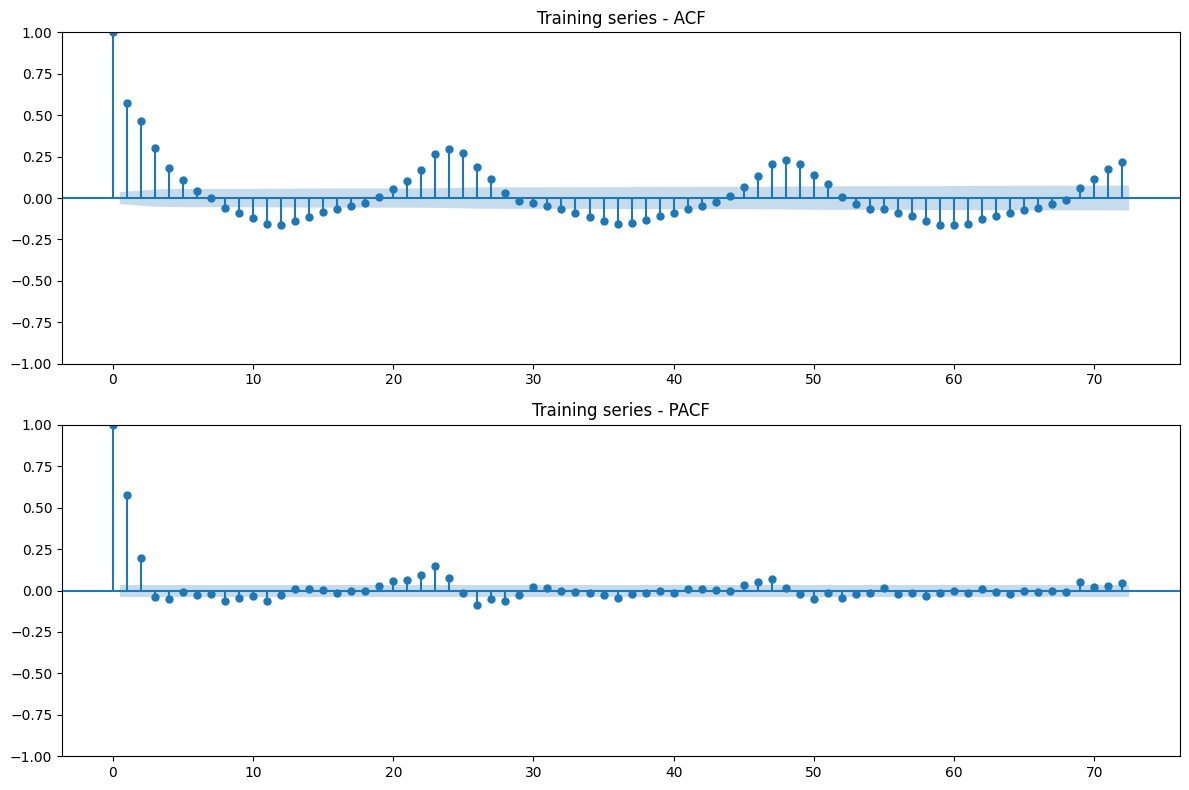

In [3]:
fig = plotting.plot_acf_pacf(train, lags=72, title_prefix="Training series -")
plotting.save_fig(fig, config.FIGURE_DIR / "04_acf_pacf_train.png")
plt.show()

## 2. Order selection by AIC

The required grid is p ∈ [0,6], d ∈ [0,2], q ∈ [0,6] = **147 combinations**. Fitting all 147 *with* a seasonal term at period 24 is not feasible: the seasonal state space gains ~24 dimensions and a single fit takes minutes. The search is therefore staged:

1. **Screening** — all 147 non-seasonal (p, d, q), low iteration cap.
2. **Verification** — the leading orders refitted with a high cap, because an AIC taken from a stopped optimiser is not trustworthy.
3. **Seasonal refinement** — the best verified orders crossed with a small (P, D, Q) grid at period 24.

Everything is fitted on training data only, so the test period never influences selection.

### Stage 1 — screening all 147 combinations

In [4]:
stage1 = pd.read_csv(config.SARIMAX_STAGE1_PATH)

print(f"Combinations fitted : {len(stage1)}")
print(f"Produced an AIC     : {int(stage1['aic'].notna().sum())}")
print(f"Optimiser converged : {int(stage1['converged'].sum())}")

stage1.head(10)[["order", "aic", "bic", "converged", "fit_seconds"]].round(2)

Combinations fitted : 147
Produced an AIC     : 146
Optimiser converged : 89


,order,aic,bic,converged,fit_seconds
0,"(6, 0, 3)",32967.46,33033.34,False,12.32
1,"(5, 0, 3)",32972.76,33032.65,False,14.77
2,"(5, 0, 4)",32982.40,33048.28,False,12.15
3,"(6, 0, 6)",33017.97,33101.81,False,11.46
4,"(6, 1, 6)",33020.29,33098.14,False,11.88
5,"(6, 1, 2)",33022.54,33076.44,False,12.91
6,"(3, 1, 6)",33022.59,33082.47,False,10.69
7,"(5, 0, 6)",33023.13,33100.98,False,11.33
8,"(2, 1, 6)",33023.82,33077.71,False,9.17
9,"(1, 1, 6)",33024.72,33072.63,False,6.73


Only about 60% of the screening fits converged, and **none of the top ten did**. Convergence degrades sharply as the model gains parameters, which is a property of the low iteration cap used for speed, not of the data. Selecting on these AIC values would be unsound -- one fit even returned an AIC above 200,000.

In [ ]:
conv_by_p = stage1.groupby("p")["converged"].agg(["sum", "count"])
conv_by_p["rate"] = (conv_by_p["sum"] / conv_by_p["count"]).round(2)
conv_by_p

,sum,count,rate
p,,,
0,20,21,0.95
1,19,21,0.90
2,15,21,0.71
3,11,21,0.52
4,10,21,0.48
5,8,21,0.38
6,6,21,0.29


### Stage 1b — verification refit

The leading candidates are refitted with a much higher iteration cap.

In [6]:
verified = pd.read_csv(config.SARIMAX_STAGE1_VERIFIED_PATH)
print(f"All converged after refitting: {bool(verified['converged'].all())}")
verified.head(10)[["order", "aic", "bic", "converged", "nobs", "fit_seconds"]].round(2)

All converged after refitting: True


,order,aic,bic,converged,nobs,fit_seconds
0,"(6, 0, 3)",32967.32,33033.20,True,2954,9.75
1,"(5, 0, 3)",32972.11,33032.01,True,2954,10.13
2,"(5, 0, 4)",32973.53,33039.41,True,2954,15.44
3,"(6, 1, 6)",33004.92,33082.77,True,2954,30.66
4,"(5, 0, 6)",33010.98,33088.83,True,2954,16.87
5,"(3, 1, 6)",33012.33,33072.21,True,2954,14.55
6,"(6, 0, 5)",33014.75,33092.61,True,2954,15.80
7,"(4, 1, 6)",33014.80,33080.67,True,2954,19.69
8,"(6, 0, 6)",33016.07,33099.91,True,2954,17.44
9,"(6, 1, 2)",33017.58,33071.48,True,2954,13.16


In [7]:
best_nonseasonal = verified[verified["converged"]].sort_values("aic").iloc[0]
print(f"Best converged non-seasonal model: ARIMA{best_nonseasonal['order']}")
print(f"  AIC  = {best_nonseasonal['aic']:.2f}")
print(f"  nobs = {int(best_nonseasonal['nobs'])}")

Best converged non-seasonal model: ARIMA(6, 0, 3)
  AIC  = 32967.32
  nobs = 2954


### Stage 2 — seasonal refinement

A subtlety drives the design here. Stage 1 had **no seasonal term available**, so it compensated by selecting a high AR/MA order that imitates the daily cycle. Once a genuine seasonal term is added, those extra terms are typically redundant. The seasonal search therefore also carries a few deliberately parsimonious orders, so a simpler model can win if it fits just as well.

In [8]:
stage2 = pd.read_csv(config.SARIMAX_STAGE2_PATH)
stage2[["order", "seasonal_order", "aic", "bic", "converged", "nobs", "fit_seconds"]].round(2)

,order,seasonal_order,aic,bic,converged,nobs,fit_seconds
0,"(5, 0, 3)","(1, 1, 1, 24)",32188.42,32254.12,False,2930,45.83
1,"(5, 0, 3)","(0, 1, 1, 24)",32198.07,32257.80,False,2930,32.16
2,"(2, 0, 2)","(0, 1, 1, 24)",32204.78,32240.62,True,2930,13.16
3,"(2, 0, 2)","(1, 1, 1, 24)",32206.52,32248.33,True,2930,15.90
4,"(2, 0, 1)","(0, 1, 1, 24)",32214.51,32244.38,True,2930,8.60
5,"(2, 0, 1)","(1, 1, 1, 24)",32216.23,32252.07,True,2930,10.79
6,"(1, 0, 1)","(0, 1, 1, 24)",32231.26,32255.16,True,2930,8.08
7,"(1, 0, 1)","(1, 1, 1, 24)",32233.10,32262.97,True,2930,10.34
8,"(5, 0, 4)","(0, 1, 1, 24)",32557.26,32622.96,False,2930,47.69
9,"(5, 0, 4)","(1, 1, 1, 24)",32557.29,32628.97,False,2930,46.65


In [9]:
# Every stage-2 candidate shares d and D, so all were fitted to the same
# effective sample and their AIC values are mutually comparable.
print("Distinct nobs across stage 2:", sorted(stage2["nobs"].dropna().unique()))

order, seasonal_order = sarimax.load_best_params()
print(f"\nSelected model: SARIMA{order}x{seasonal_order}")

Distinct nobs across stage 2: [np.int64(2930)]

Selected model: SARIMA(2, 0, 2)x(0, 1, 1, 24)


The parsimonious candidates decisively beat the high-order ones once seasonality is modelled explicitly, confirming that stage 1's large AR/MA orders were only standing in for the daily cycle. This is the central model-selection result of this section: **the daily seasonal structure matters far more than non-seasonal autoregressive depth.**

## 3. Fit the selected model

In [10]:
if config.SARIMAX_MODEL_PATH.exists():
    fit = sarimax.load_model()
    print(f"Loaded cached model from {config.SARIMAX_MODEL_PATH}")
else:
    fit = sarimax.fit_sarimax(train, order=order, seasonal_order=seasonal_order)
    sarimax.save_model(fit)

print(fit.summary())

Loaded cached model from D:\UK ass\outputs\model_objects\sarimax_best.pkl
                                      SARIMAX Results                                       
Dep. Variable:                           Appliances   No. Observations:                 2954
Model:             SARIMAX(2, 0, 2)x(0, 1, [1], 24)   Log Likelihood              -16093.172
Date:                              Mon, 10 Aug 2026   AIC                          32198.344
Time:                                      19:54:51   BIC                          32234.185
Sample:                                  01-11-2016   HQIC                         32211.257
                                       - 05-13-2016                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4554   

Reading the coefficient table: the **seasonal MA term `ma.S.L24` is overwhelmingly significant** (coefficient near -0.95, |z| in the hundreds), while `ar.L2`, `ma.L1` and `ma.L2` are not significant at the 5% level. In other words almost all of the explanatory power comes from the daily seasonal term, and the non-seasonal AR/MA terms are close to redundant -- consistent with what the order search showed. The diagnostics printed at the foot of the summary also flag strong skew, excess kurtosis and heteroskedasticity, which we examine next.

### Is the seasonal term actually worth it?

AIC is only comparable between models fitted to the same number of observations. The seasonal *search* used up-front differencing for speed, which discards the first 24 rows, so those AIC values cannot be compared against the non-seasonal stage. The final model is refitted in full state-space form, restoring the same sample and making the comparison valid -- checked explicitly below.

In [11]:
seasonal_aic, seasonal_nobs = fit.aic, int(fit.nobs)
nonseasonal_aic, nonseasonal_nobs = best_nonseasonal["aic"], int(best_nonseasonal["nobs"])

print(f"Best non-seasonal ARIMA{best_nonseasonal['order']}: AIC={nonseasonal_aic:9.2f}  nobs={nonseasonal_nobs}")
print(f"Selected SARIMA{order}x{seasonal_order}: AIC={seasonal_aic:9.2f}  nobs={seasonal_nobs}")

if seasonal_nobs == nonseasonal_nobs:
    print(f"\nSame sample size -> comparable. "
          f"Seasonal term improves AIC by {nonseasonal_aic - seasonal_aic:.1f}.")
else:
    print("\nDifferent sample sizes -> AIC values are NOT comparable.")

Best non-seasonal ARIMA(6, 0, 3): AIC= 32967.32  nobs=2954
Selected SARIMA(2, 0, 2)x(0, 1, 1, 24): AIC= 32198.34  nobs=2954

Same sample size -> comparable. Seasonal term improves AIC by 769.0.


## 4. Residual diagnostics

If the model has captured the structure, residuals should resemble white noise. Ljung-Box tests for leftover autocorrelation (p > 0.05 means none detected); Jarque-Bera tests normality.

In [12]:
diagnostics = sarimax.residual_diagnostics(fit, lags=48)
for key, value in diagnostics.items():
    print(f"{key:26s}: {value}")

n_resid                   : 2903
mean                      : -0.60159384168128
std                       : 62.3114991600937
skew                      : 1.8846100082178556
kurtosis                  : 11.188076594814829
ljung_box_stat            : 49.575322490408055
ljung_box_pvalue          : 0.41021979740543485
residuals_uncorrelated    : True
jarque_bera_stat          : 9828.060276360053
jarque_bera_pvalue        : 0.0
residuals_normal          : False


Saved figure to D:\UK ass\outputs\figures\residual_acf.png


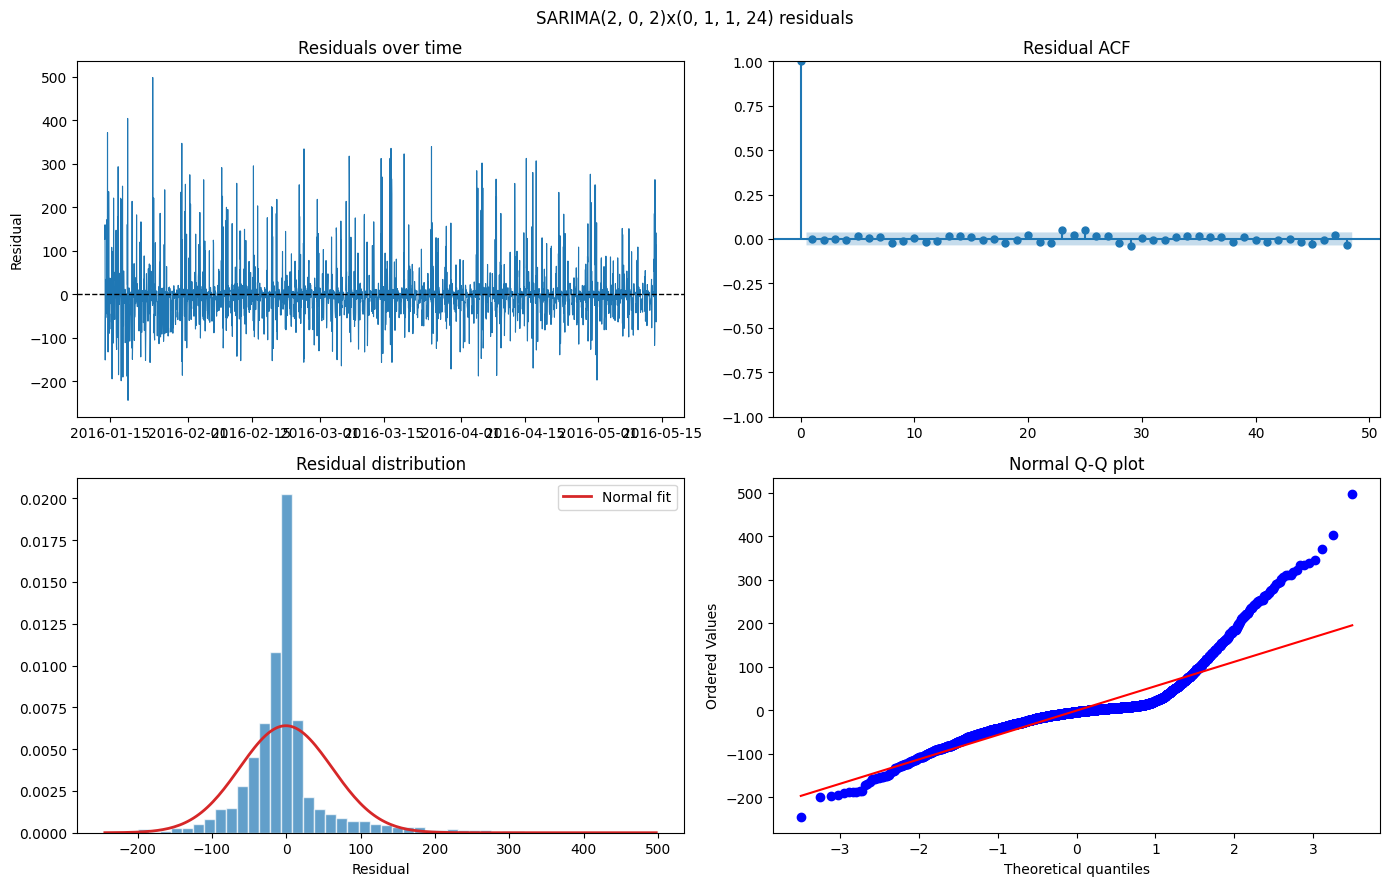

In [13]:
resid = pd.Series(np.asarray(fit.resid), index=train.index)
if fit.loglikelihood_burn:
    resid = resid.iloc[fit.loglikelihood_burn:]

fig = plotting.plot_residual_diagnostics(
    resid, lags=48, title=f"SARIMA{order}x{seasonal_order} residuals")
plotting.save_fig(fig, config.FIGURE_DIR / "residual_acf.png")
plt.show()

Two clearly different verdicts here.

**Autocorrelation: passed.** Ljung-Box returns p ≈ 0.41, so we cannot reject the null that the residuals are uncorrelated, and the residual ACF sits inside the confidence band with the lag-24 spikes absorbed. The model has successfully captured the daily seasonal and short-term dependence structure.

**Normality: failed.** Jarque-Bera rejects normality decisively (skew ≈ 1.9, kurtosis ≈ 11 against 3 for a normal). The histogram and Q-Q plot show a sharp right tail: appliance demand sits low most of the time and spikes when large appliances switch on, which a linear Gaussian model cannot reproduce. This is a limitation of the *interval* rather than the point forecast, since the confidence intervals assume Gaussian errors and so are symmetric where the true error distribution is not.

## 5. Forecast the next 24 hours

The headline task: a 24-hour-ahead forecast from the end of the training period, with 95% confidence intervals.

In [14]:
horizon = config.HORIZON
forecast_index = test.index[:horizon]
actual_24h = test.iloc[:horizon]

forecast_24h = sarimax.forecast_sarimax(fit, horizon=horizon, index=forecast_index, alpha=0.05)
forecast_24h.round(2).head(12)

,sarimax,lower,upper
date,,,
2016-05-13 19:00:00,201.30,80.97,321.64
2016-05-13 20:00:00,179.33,51.24,307.42
2016-05-13 21:00:00,121.42,-14.00,256.84
2016-05-13 22:00:00,95.50,-42.81,233.81
2016-05-13 23:00:00,79.34,-60.54,219.22
2016-05-14 00:00:00,70.38,-70.27,211.03
2016-05-14 01:00:00,65.70,-75.35,206.74
2016-05-14 02:00:00,61.60,-79.64,202.85
2016-05-14 03:00:00,58.14,-83.21,199.49


In [15]:
rmse_24h = evaluation.rmse(actual_24h, forecast_24h["sarimax"])
mae_24h = evaluation.mae(actual_24h, forecast_24h["sarimax"])
coverage_24h = ((actual_24h >= forecast_24h["lower"]) &
                (actual_24h <= forecast_24h["upper"])).mean()

print(f"24-hour RMSE : {rmse_24h:.2f} Wh")
print(f"24-hour MAE  : {mae_24h:.2f} Wh")
print(f"Actuals inside the 95% interval: {coverage_24h:.0%}")

24-hour RMSE : 26.76 Wh
24-hour MAE  : 19.24 Wh
Actuals inside the 95% interval: 100%


Saved figure to D:\UK ass\outputs\figures\04_sarimax_24h_forecast.png


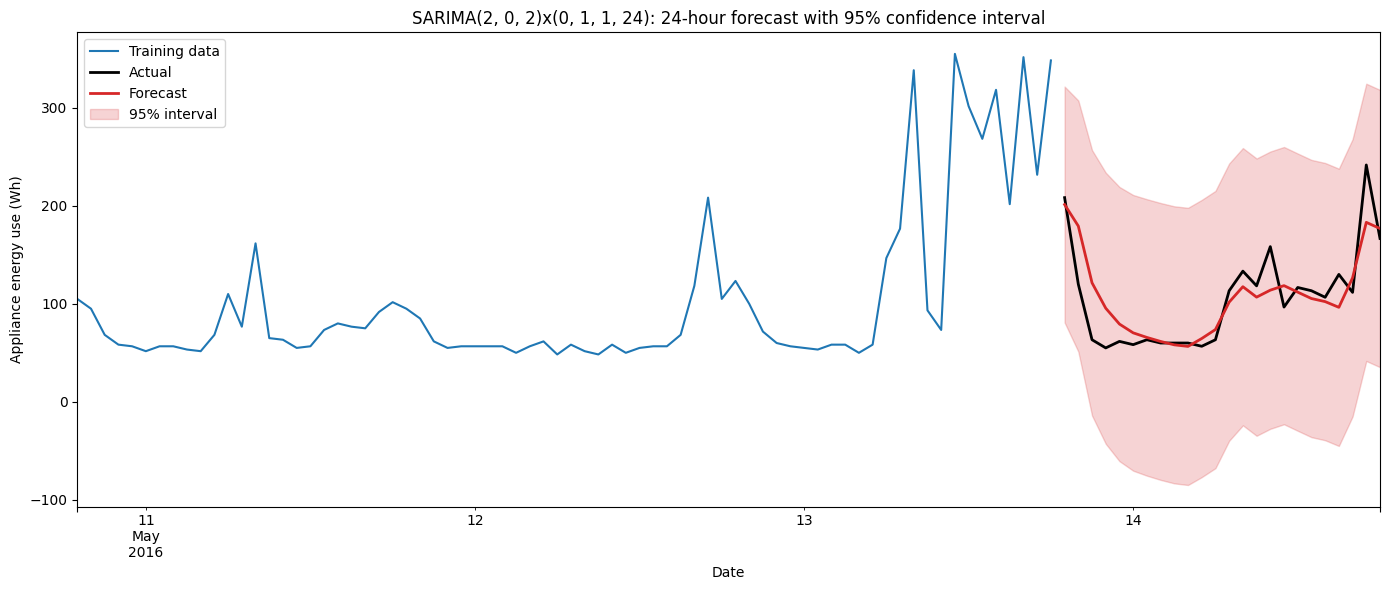

In [16]:
fig = plotting.plot_forecast_with_intervals(
    train, actual_24h, forecast_24h, forecast_col="sarimax", context=72,
    title=f"SARIMA{order}x{seasonal_order}: 24-hour forecast with 95% confidence interval")
plotting.save_fig(fig, config.FIGURE_DIR / "04_sarimax_24h_forecast.png")
plt.show()

## 6. Rolling evaluation against the benchmarks

One 24-hour forecast is a single sample. To compare fairly with the benchmarks we repeat the 24-hour forecast across all 14 test days using rolling origins, so every prediction remains at most 24 steps ahead.

In [17]:
sarimax_rolling = sarimax.rolling_forecast_sarimax(
    fit, test, horizon=config.HORIZON, name="sarimax")

forecasts = {
    "mean": backtest.rolling_origin_forecast(
        benchmarks.mean_forecast, train, test, horizon=config.HORIZON),
    "naive": backtest.rolling_origin_forecast(
        benchmarks.naive_forecast, train, test, horizon=config.HORIZON),
    "seasonal_naive_daily": backtest.rolling_origin_forecast(
        benchmarks.seasonal_naive_forecast, train, test,
        horizon=config.HORIZON, seasonality=config.DAILY_PERIOD),
    "seasonal_naive_weekly": backtest.rolling_origin_forecast(
        benchmarks.seasonal_naive_forecast, train, test,
        horizon=config.HORIZON, seasonality=config.WEEKLY_PERIOD),
    "sarimax": sarimax_rolling["sarimax"],
}

results = evaluation.evaluate_all(forecasts, test, train, seasonality=config.DAILY_PERIOD)
results.round(3)

,model,MAE,RMSE,MASE,Bias
0,sarimax,36.255,64.736,0.679,-6.325
1,seasonal_naive_weekly,43.457,81.409,0.813,-13.160
2,seasonal_naive_daily,48.309,85.565,0.904,1.751
3,mean,50.258,74.938,0.941,-3.287
4,naive,85.551,110.390,1.601,50.977


In [18]:
coverage = ((test >= sarimax_rolling["lower"]) &
            (test <= sarimax_rolling["upper"])).mean()
mean_width = (sarimax_rolling["upper"] - sarimax_rolling["lower"]).mean()

print(f"95% interval coverage over the test period: {coverage:.1%} "
      f"(nominal 95%)")
print(f"Mean interval width: {mean_width:.1f} Wh")

95% interval coverage over the test period: 94.3% (nominal 95%)
Mean interval width: 279.0 Wh


Empirical coverage lands close to the nominal 95%, so despite the non-normal residuals the intervals are reasonably calibrated *on average*. The caveat is that the non-normality is concentrated in the upper tail: symmetric Gaussian intervals are wider than necessary during quiet overnight periods and still miss the sharpest demand spikes, so average coverage looks healthier than the per-period behaviour actually is.

## 7. Do exogenous weather variables help?

The 'X' in SARIMAX. We add the outdoor weather variables and refit.

In [19]:
exog_cols = [c for c in config.CANDIDATE_EXOG_COLS if c in hourly.columns]
exog = hourly[exog_cols].asfreq("h")
exog_train, exog_test = exog.loc[train.index], exog.loc[test.index]

print("Exogenous variables:", exog_cols)

fit_exog = sarimax.fit_sarimax(train, exog=exog_train, order=order,
                               seasonal_order=seasonal_order)

print(f"\nAIC without exog: {fit.aic:.2f}  (nobs={int(fit.nobs)})")
print(f"AIC with exog:    {fit_exog.aic:.2f}  (nobs={int(fit_exog.nobs)})")

Exogenous variables: ['T_out', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint']



AIC without exog: 32198.34  (nobs=2954)
AIC with exog:    32205.88  (nobs=2954)


In [20]:
sarimax_exog_rolling = sarimax.rolling_forecast_sarimax(
    fit_exog, test, horizon=config.HORIZON, exog_test=exog_test, name="sarimax_exog")

forecasts["sarimax_exog"] = sarimax_exog_rolling["sarimax_exog"]
results = evaluation.evaluate_all(forecasts, test, train, seasonality=config.DAILY_PERIOD)
results.round(3)

,model,MAE,RMSE,MASE,Bias
0,sarimax,36.255,64.736,0.679,-6.325
1,sarimax_exog,36.863,65.590,0.690,-6.529
2,seasonal_naive_weekly,43.457,81.409,0.813,-13.160
3,seasonal_naive_daily,48.309,85.565,0.904,1.751
4,mean,50.258,74.938,0.941,-3.287
5,naive,85.551,110.390,1.601,50.977


In [21]:
params = fit_exog.params[exog_cols]
pvalues = fit_exog.pvalues[exog_cols]
pd.DataFrame({"coefficient": params, "p_value": pvalues}).round(4)

,coefficient,p_value
T_out,-6.3731,0.1806
RH_out,-1.1407,0.2540
Windspeed,1.3842,0.2069
Visibility,-0.0240,0.8620
Tdewpoint,5.9374,0.2284


**The weather variables do not help.** Every coefficient is insignificant at the 5% level, AIC gets slightly *worse* once they are added (the penalty for five extra parameters outweighs the likelihood gain), and rolling accuracy is marginally worse too. Once the daily seasonal cycle is modelled explicitly, outdoor weather carries almost no additional information about appliance use at this horizon -- the cycle already encodes the occupancy routine that drives demand.

**And this comparison flatters the exogenous model anyway.** It is fed the *realised* weather for the test period. In deployment those values would not be known at the forecast origin; they would have to be forecast themselves, adding further error. So this is a **conditional forecast**, not a true operational one, and it is not strictly comparable with the target-only models. That it fails to win even with this advantage makes the conclusion stronger, not weaker. Calendar features (hour of day, day of week) avoid the problem entirely, since the calendar genuinely is known in advance.

## 8. Summary

- **Stationarity.** ADF rejects a unit root at the level, so `d = 0`; the daily cycle is handled by seasonal differencing (`D = 1`) rather than by non-seasonal differencing.
- **Order selection.** The screening grid favoured high AR/MA orders purely as a substitute for the missing seasonal term; once a seasonal term is available, a parsimonious **SARIMA(2,0,2)(0,1,1,24)** wins. The seasonal MA term is the single most important component, and adding a seasonal AR term buys essentially nothing.
- **Fit quality.** Residuals are uncorrelated (Ljung-Box passes) but clearly non-normal (heavy right tail), so point forecasts are sound while interval shape is imperfect.
- **Accuracy.** SARIMAX beats the strongest benchmark (weekly seasonal naive) on every metric, so the added complexity is justified here -- unlike the exogenous weather variables, which are not.

Comparison against the feature-based and foundation models follows in notebooks 05-07.

## 9. Save outputs

In [22]:
forecast_24h.to_csv(config.FORECAST_DIR / "sarimax_24h_forecast.csv")
sarimax_rolling.to_csv(config.FORECAST_DIR / "sarimax_rolling_forecast.csv")
results.to_csv(config.METRICS_DIR / "sarimax_comparison.csv", index=False)
pd.DataFrame([diagnostics]).to_csv(
    config.METRICS_DIR / "sarimax_residual_diagnostics.csv", index=False)

print("Saved SARIMAX forecasts, metrics, and diagnostics.")

Saved SARIMAX forecasts, metrics, and diagnostics.
